# The 9/9/9 Fan Experience Index

By Tai Ryan - A2E9348, Bailey Gutierrez A197841, Cyrus Isaacs A1w5n68


## 1. Abstract

Fan enjoyment can be a very subjective and hard to quantify aspect of any sporting event. For our final project, we decided to look at quantifying fan enjoyment and also a specific way to experience a baseball game. The “9-9-9 Challenge” is a challenge specific to baseball where the spectator consumes nine hotdogs and nine beers in nine innings, with one dog and one beer consumed per inning. This project is in no way suggesting or encouraging anyone to participate in the challenge. We are more interested in using the challenge as a unique way to do data analysis in the context of baseball. To quantify the challenge, our project creates a normalized index that combines affordability of the challenge as well as fan enjoyment. The affordability only includes the cost of the concessions as we were unable to find a reliable source for historic ticket prices. The fan enjoyment aspect is harder to quantify as fan enjoyment is very subjective which is a shortcoming of our project. That being said, our index quantifies fan enjoyment through two separate categories (and should be treated as a measure of such): game quality, and player quality. 2024 is then used as our baseline season to create the normalized index. 2025 is tested to see if the variation in the index changes or if it remains the same. Completed games in 2026 are also scored. From our results we then can determine, given our definition of enjoyment, which completed games would have been optimal in the context of affordability and enjoyment, for the 9-9-9 challenge.

## 2. Introduction

Fan enjoyment is one of the most important aspects of attending a sporting event, yet it is also one of the most difficult to measure because different fans value different parts of the experience. Major League Baseball provides a useful setting for studying fan experience because there are many games each season and extensive publicly available data on teams, players, game outcomes, and stadium concessions.

To create a measurable framework, this project uses the 9/9/9 Challenge as a way to incorporate affordability into the analysis through concession prices. The challenge provides a consistent benchmark for comparing costs across stadiums. We then combine affordability with measures of game quality and player quality to create a normalized fan enjoyment index.

Using the 2024 season as a baseline, we evaluate games from the 2025 season and completed games from 2026 to determine which games offered the best balance between affordability and enjoyment according to our defined metrics. This leads to our central research question: which MLB games provide the most enjoyable and affordable experience for fans when evaluated through the framework of the 9/9/9 Challenge?

## 3. Methodology

To compare MLB games across seasons, we construct a weighted normalized index rather than directly predicting wins. Each game is represented once per team, and all variables are standardized using the 2024 season as the baseline. The index combines game quality, lineup superstar factor, current-season leader factor, concession affordability, and late-game staleness.

The raw weighted index is calculated as:

```text
raw index =
0.35(game quality z)
+ 0.15(lineup superstar factor z)
+ 0.10(current-season leader factor z)
- 0.25(concession cost z)
- 0.15(staleness z)
```

Positive weights are assigned to variables that should improve the fan experience: realized game quality, lineup superstar/performance rating, and current-season player relevance. Negative weights are assigned to variables that reduce 9/9/9 value: higher concession cost and late-game staleness after the assumed concession window closes.

The final score is normalized again so it is easier to interpret:

```text
final index = 100 + 10(raw index z-score)
```

The project also includes a simple holdout check. The 2024 season is used to define the baseline normalization and high-index threshold, while 2025 is treated as a test season. The holdout check evaluates whether pre-game available variables, such as concession cost, lineup superstar factor, current-season leader factor, and home/away status, can identify games that later score highly under the retrospective 9/9/9 index. Performance is evaluated with AUC, where higher values indicate better ability to distinguish between stronger and weaker fan experiences.

In [911]:
from pathlib import Path

import pandas as pd

ROOT = Path.cwd()
DATA = ROOT / "data" / "processed"

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ModuleNotFoundError:
    HAS_MATPLOTLIB = False
    print("matplotlib is not installed; plot cells will be skipped.")

## 4. Data

The processed CSV files used in this notebook were created from reproducible scripts in the `scripts/` folder. The notebook starts from prepared data so the final report remains readable and does not require thousands of API calls during grading.

### Data Collection Summary

The data for this project was collected from two main types of sources. MLB game, player, lineup, weather, timing, and award data came from MLB StatsAPI. The data-building script downloaded regular-season schedules, live game feeds, box scores, player season statistics, player awards, and date-bounded current-season statistics. These API responses were cached locally so the analysis could be reproduced without repeatedly making thousands of web requests.

Concession prices were collected from public secondary sources that reported MLB beer and hot dog prices by team or ballpark. These sources were cleaned into team-season concession tables for 2024, 2025, and 2026. The 2024 prices came from the existing prepared project data using public beer and hot dog sources, while 2025 and 2026 prices used the best available public all-team concession price tables and validation sources. The final processed datasets were written as CSV files in `data/processed/` and are loaded below.

In [912]:
panel = pd.read_csv(DATA / "final_project_team_game_999_optimality_2024_2026.csv", parse_dates=["game_date"])
sources = pd.read_csv(DATA / "final_project_source_notes.csv")
validation = pd.read_csv(DATA / "final_project_validation_summary_2024_2026.csv")
concessions = pd.read_csv(DATA / "final_project_concessions_2024_2026.csv")
star_scores = pd.read_csv(DATA / "final_project_player_star_scores_2024_2026.csv")
normalization = pd.read_csv(DATA / "final_project_2024_normalization_parameters.csv")
bullpen_results = pd.read_csv(DATA / "final_project_bullpen_staleness_model_results.csv")
pregame_auc = pd.read_csv(DATA / "final_project_pregame_auc_backtest_2025.csv")

print(f"Final panel rows: {len(panel):,}")
print(f"Unique games: {panel['game_pk'].nunique():,}")
seasons = [int(x) for x in sorted(panel["season"].unique())]
print(f"Seasons: {seasons}")
print("Latest game date by season:")
print(panel.groupby("season")["game_date"].max())

Final panel rows: 11,490
Unique games: 5,745
Seasons: [2024, 2025, 2026]
Latest game date by season:
season
2024   2024-09-30
2025   2025-09-28
2026   2026-05-31
Name: game_date, dtype: datetime64[us]


In [913]:
validation

,season,split,team_game_rows,games,teams_with_concessions,missing_beer_prices,missing_hot_dog_prices,missing_post_cutoff_minutes,mean_999_index,sd_999_index
0,2024,train,4858,2429,30,0,0,4,100.000,10.000
1,2025,test,4860,2430,30,0,0,10,99.833,10.171
2,2026,score_2026,1772,886,30,0,0,0,99.946,9.840


### Data Sources And Caveats

The main baseball data comes from MLB StatsAPI, including schedules, game results, lineups, starters, attendance, weather, timing, player statistics, and awards. Concession prices come from public secondary sources that compare beer and hot dog prices across MLB stadiums.

We originally wanted to include average ticket prices or ticket-price quartiles, but we could not find a reliable historical source for primary-market game-level ticket prices. Because of that, ticket prices are excluded from the model. This means the index measures the affordability of the 9/9/9 concession challenge after entering the stadium, not the total cost of attending a game.

Concession prices also require caution because there is no consistent official source that covers every team across every year. The final dataset uses the best available public sources for each season, so year-to-year concession comparisons should be interpreted as public estimates rather than exact official team prices. Completed 2026 games are included only through the available data in the processed dataset.

In [914]:
sources[["dataset", "source", "url", "use_in_project", "caveat"]]

,dataset,source,url,use_in_project,caveat
0,concessions_2024,Existing prepared project file using 2024 publ...,https://1075thefan.com/playlist/price-of-beer-...,Beer and hot dog prices for 2024 training-seas...,Secondary sources; concession values are treat...
1,concessions_2025,"Cheapism all-team table, Yahoo/List Wire repub...",https://www.cheapism.com/mlb-beer-hot-dog-pric...,Best-available public 2025 concession estimate...,A clean all-team 2025 text table was not expos...
2,concessions_2026,Cheapism 2026 all-team MLB beer and hot dog pr...,https://www.cheapism.com/mlb-beer-hot-dog-pric...,2026 concession costs for current-season scoring.,Secondary public source; prices are the lowest...
3,game_features,MLB StatsAPI schedule and live game feed endpo...,https://statsapi.mlb.com/api/v1/schedule | htt...,"Game dates, teams, venues, attendance, weather...",Post-7th timing is measured from the first pla...
4,player_performance,MLB StatsAPI season hitting and pitching stati...,https://statsapi.mlb.com/api/v1/stats?stats=se...,Prior-season player performance component for ...,Uses prior-season regular-season statistics on...
5,player_accolades,MLB StatsAPI people awards endpoint.,https://statsapi.mlb.com/api/v1/people/{person...,Career award component for the superstar factor.,Awards are counted only if awarded before the ...
6,current_season_leader_factor,MLB StatsAPI by-date-range hitting and pitchin...,https://statsapi.mlb.com/api/v1/stats?stats=by...,Lagged in-season leader factor for players lea...,Uses only stats through the day before the gam...
7,ticket_prices,Not included in the training/test model by pro...,NaN,Can be added later as a game-specific adjustme...,Avoids resale data and avoids needing unavaila...


### Concession Price Source Selection

Concession prices required special handling because the project needed team-level beer and hot dog prices for 2024, 2025, and 2026, but there is no single official MLB dataset that cleanly reports both prices for all teams across all three seasons.

Source-selection criteria:
- The source had to report MLB beer and/or hot dog prices at the team or ballpark level.
- The data had to cover as many teams as possible, ideally all 30 teams.
- The source had to be public and citeable.
- When multiple sources existed, the final dataset favored the source with the clearest team-level values and best coverage.
- Ticket and resale prices were not used in the concession table.

The table below summarizes the concession sources selected for the final analysis.

In [915]:
concession_source_selection = (
    concessions.groupby(
        ["season", "source_label", "source_url", "source_quality", "season_basis"],
        dropna=False,
        as_index=False,
    )
    .agg(
        teams_covered=("team", "nunique"),
        min_beer_price=("beer_price", "min"),
        max_beer_price=("beer_price", "max"),
        min_hot_dog_price=("hot_dog_price", "min"),
        max_hot_dog_price=("hot_dog_price", "max"),
        min_999_cost=("concession_999_cost", "min"),
        max_999_cost=("concession_999_cost", "max"),
    )
    .round(2)
)

concession_source_selection

,season,source_label,source_url,source_quality,season_basis,teams_covered,min_beer_price,max_beer_price,min_hot_dog_price,max_hot_dog_price,min_999_cost,max_999_cost
0,2024,2024 public secondary sources: Statista-derive...,https://1075thefan.com/playlist/price-of-beer-...,high,2024 public beer and hot dog sources,30,3.080,15.400,2.550,8.390,63.990,210.510
1,2025,Cheapism/Yahoo all-team MLB beer and hot dog p...,https://www.cheapism.com/mlb-beer-hot-dog-prices/,medium,best available 2025 public estimate,30,3.000,16.000,3.000,8.000,72.000,216.000
2,2026,Cheapism/Yahoo all-team MLB beer and hot dog p...,https://www.cheapism.com/mlb-beer-hot-dog-prices/,high,2026 public table,30,3.000,16.000,3.000,8.000,72.000,216.000


The next table shows the final beer and hot dog prices used in the index. Each row is one team-season.

In [916]:
selected_concession_prices = concessions[
    [
        "season",
        "team",
        "beer_price",
        "hot_dog_price",
        "concession_999_cost",
        "source_quality",
        "season_basis",
        "source_label",
    ]
].sort_values(["season", "team"])

selected_concession_prices

,season,team,beer_price,hot_dog_price,concession_999_cost,source_quality,season_basis,source_label
0,2024,Arizona Diamondbacks,5.130,2.990,73.080,high,2024 public beer and hot dog sources,2024 public secondary sources: Statista-derive...
1,2024,Atlanta Braves,5.130,3.990,82.080,high,2024 public beer and hot dog sources,2024 public secondary sources: Statista-derive...
2,2024,Baltimore Orioles,11.290,4.100,138.510,high,2024 public beer and hot dog sources,2024 public secondary sources: Statista-derive...
3,2024,Boston Red Sox,10.790,6.250,153.360,high,2024 public beer and hot dog sources,2024 public secondary sources: Statista-derive...
4,2024,Chicago Cubs,10.780,7.990,168.930,high,2024 public beer and hot dog sources,2024 public secondary sources: Statista-derive...
...,...,...,...,...,...,...,...,...
85,2026,St. Louis Cardinals,12.000,7.750,177.750,high,2026 public table,Cheapism/Yahoo all-team MLB beer and hot dog p...
86,2026,Tampa Bay Rays,5.140,5.000,91.260,high,2026 public table,Cheapism/Yahoo all-team MLB beer and hot dog p...
87,2026,Texas Rangers,11.500,7.190,168.210,high,2026 public table,Cheapism/Yahoo all-team MLB beer and hot dog p...
88,2026,Toronto Blue Jays,4.560,5.000,86.040,high,2026 public table,Cheapism/Yahoo all-team MLB beer and hot dog p...


### Cleaning And Unit Of Analysis

The final unit of analysis is a team-game, meaning each MLB game appears once for each team. This structure allows the same game to receive different scores for the two teams because game quality, player appeal, and current-season leader factors are team-specific.

Team names were standardized across sources, postponed or incomplete games were removed, and concession prices were merged by team and season. Actual starting lineups were used for the superstar factor. Current-season leader variables were lagged through the day before each game to avoid same-game leakage.

In [917]:
summary_by_season = (
    panel.groupby("season")
    .agg(
        games=("game_pk", "nunique"),
        team_game_rows=("game_pk", "size"),
        teams=("team", "nunique"),
        avg_index=("999_optimality_index", "mean"),
        sd_index=("999_optimality_index", "std"),
        avg_999_cost=("concession_999_cost", "mean"),
        avg_game_quality=("game_quality_raw", "mean"),
        avg_superstar=("lineup_superstar_factor_raw", "mean"),
        avg_current_leader=("current_season_leader_factor_raw", "mean"),
        avg_staleness=("staleness_raw", "mean"),
    )
    .round(3)
)

summary_by_season

,games,team_game_rows,teams,avg_index,sd_index,avg_999_cost,avg_game_quality,avg_superstar,avg_current_leader,avg_staleness
season,,,,,,,,,,
2024,2429,4858,30,100.000,10.001,118.467,5.801,1.796,0.835,36.090
2025,2430,4860,30,99.833,10.172,121.365,5.861,1.904,0.819,36.407
2026,886,1772,30,99.946,9.843,121.210,5.710,1.991,0.872,37.349


### Created Variables And Normalization

The raw data was transformed into created variables that represent affordability and fan experience. Concession prices are mostly fixed within a season, so most game-level variation comes from realized game quality, player appeal, current-season relevance, and late-game staleness.

Main variables:
- `concession_999_cost`: cost of 9 beers and 9 hot dogs.
- `game_quality_raw`: realized game quality for that team.
- `lineup_superstar_factor_raw`: prior performance and career awards for actual lineup players.
- `current_season_leader_factor_raw`: lagged current-season league-leader signal.
- `staleness_raw`: late-game duration after the assumed concession window closes.
- `999_optimality_index`: final normalized score.

In [918]:
created_variable_cols = [
    "concession_999_cost",
    "game_quality_raw",
    "lineup_superstar_factor_raw",
    "current_season_leader_factor_raw",
    "staleness_raw",
    "999_optimality_index",
]

component_stats = (
    panel.groupby("season")[created_variable_cols]
    .agg(["mean", "std", "min", "max"])
    .round(3)
)

component_stats

concession_999_cost                       game_quality_raw        \
                      mean    std    min     max             mean   std   
season                                                                    
2024               118.467 32.095 63.990 210.510            5.801 5.116   
2025               121.365 38.527 72.000 216.000            5.861 5.312   
2026               121.210 38.555 72.000 216.000            5.710 5.150   

                     lineup_superstar_factor_raw                    \
          min    max                        mean   std   min   max   
season                                                               
2024   -5.950 30.450                       1.796 1.024 0.000 5.184   
2025   -7.350 30.750                       1.904 1.199 0.000 6.145   
2026   -4.950 25.650                       1.991 1.184 0.150 6.648   

       current_season_leader_factor_raw                   staleness_raw  \
                                   mean   std   min   max          mean   
season                                                                    
2024                              0.835 0.469 0.000 3.000        36.090   
2025                              0.819 0.474 0.000 2.675        36.407   
2026                              0.872 0.400 0.000 2.105        37.349   

                             999_optimality_index                        
          std    min     max                 mean    std    min     max  
season                                                                   
2024   16.210  6.972 275.479              100.000 10.001 48.831 135.467  
2025   15.278 12.807 202.414               99.833 10.172 66.452 148.375  
2026   14.805 13.578 130.617               99.946  9.843 62.727 142.717

In [919]:
normalization

,variable,train_2024_mean,train_2024_sd
0,game_quality_raw,5.801,5.115
1,lineup_superstar_factor_raw,1.796,1.024
2,current_season_leader_factor_raw,0.835,0.469
3,concession_999_cost,118.467,32.092
4,staleness_raw,36.090,16.208
5,999_optimality_raw_base_to_index,0.000,0.560
6,999_optimality_raw_to_index,0.000,0.532


### Affordability: 9/9/9 Cost

The concession cost variable measures the affordability part of the index:

```text
concession_999_cost = 9(beer price) + 9(hot dog price)
```

This variable stays fixed for each team within a given season because teams generally do not change benchmark concession prices game by game. Higher concession costs increase the total cost of completing the 9/9/9 challenge and therefore lower the overall index.

In [920]:
concessions_summary = (
    concessions.groupby("season")
    .agg(
        teams=("team", "nunique"),
        min_999_cost=("concession_999_cost", "min"),
        median_999_cost=("concession_999_cost", "median"),
        mean_999_cost=("concession_999_cost", "mean"),
        max_999_cost=("concession_999_cost", "max"),
    )
    .round(2)
)

concessions_summary

,teams,min_999_cost,median_999_cost,mean_999_cost,max_999_cost
season,,,,,
2024,30,63.990,118.120,118.460,210.510
2025,30,72.000,120.780,121.360,216.000
2026,30,72.000,120.780,121.360,216.000


In [921]:
concessions.sort_values(["season", "concession_999_cost"]).groupby("season").head(5)[
    ["season", "team", "beer_price", "hot_dog_price", "concession_999_cost", "source_quality"]
]

,season,team,beer_price,hot_dog_price,concession_999_cost,source_quality
28,2024,Toronto Blue Jays,4.560,2.550,63.990,high
0,2024,Arizona Diamondbacks,5.130,2.990,73.080,high
14,2024,Miami Marlins,5.140,3.000,73.260,high
1,2024,Atlanta Braves,5.130,3.990,82.080,high
16,2024,Minnesota Twins,5.130,3.990,82.080,high
39,2025,Detroit Tigers,5.000,3.000,72.000,medium
30,2025,Arizona Diamondbacks,5.130,3.070,73.800,medium
44,2025,Miami Marlins,5.140,3.080,73.980,medium
46,2025,Minnesota Twins,4.990,4.100,81.810,medium
31,2025,Atlanta Braves,5.130,4.100,83.070,medium


### Game Quality Score

The game quality score is retrospective and uses completed game outcomes. It measures realized game quality from each team's perspective by rewarding wins, quality starts, scoring, home runs, and run differential.

```text
game_quality_raw =
2.00(win)
+ 1.50(quality start)
+ 0.65(runs)
+ 1.25(home runs)
+ 0.35(run differential)
```

Because this variable uses outcomes such as wins, runs, and home runs, it is only available after the game is complete. It is included in the retrospective index to measure how enjoyable the game actually was under the project's definition of fan experience.

### Player Appeal: Superstar Factor

The superstar factor is included because star players can increase fan appeal and make a game more exciting to attend. The player appeal component uses actual lineups, so the rating reflects the players who appeared in that specific game rather than only the team's general reputation.

The superstar factor uses prior-season performance and official MLB awards before the target season. Awards capture career recognition and reputation, while recent performance captures current on-field ability. The `performance_raw` score measures recent statistical ability, while the full superstar score combines recent performance with career awards to better reflect both ability and fan appeal.

In [922]:
star_display_cols = [
    "target_season",
    "season_rank",
    "player_name",
    "player_star_score",
    "performance_raw",
    "career_accolade_points",
    "career_mvp_count",
    "career_cy_young_count",
    "career_hank_aaron_count",
    "career_world_series_mvp_count",
    "career_all_star_count",
]

star_rankings = star_scores.copy()
star_rankings["season_rank"] = (
    star_rankings.groupby("target_season")["player_star_score"]
    .rank(method="first", ascending=False)
    .astype(int)
)

star_rankings.sort_values(["target_season", "season_rank"])[star_display_cols].head(30)

,target_season,season_rank,player_name,player_star_score,performance_raw,career_accolade_points,career_mvp_count,career_cy_young_count,career_hank_aaron_count,career_world_series_mvp_count,career_all_star_count
0,2024,1,Mike Trout,6.944,0.797,97,3,0,2,0,11
1,2024,2,Mookie Betts,5.428,2.198,54,1,0,0,0,7
2,2024,3,Justin Verlander,5.360,1.584,62,1,3,0,0,9
3,2024,4,Paul Goldschmidt,5.088,1.377,61,1,0,2,0,7
4,2024,5,Clayton Kershaw,5.067,1.287,62,1,3,0,0,10
...,...,...,...,...,...,...,...,...,...,...,...
25,2024,26,Francisco Lindor,2.658,1.651,21,0,0,0,0,4
26,2024,27,Andrew McCutchen,2.530,0.636,34,1,0,0,0,5
27,2024,28,José Ramírez,2.461,1.384,22,0,0,0,0,5
28,2024,29,Pete Alonso,2.452,2.193,10,0,0,0,0,3


### Player Performance Diagnostic

The table and chart below show the performance-only component of the superstar score. This diagnostic is useful because `performance_raw` can be negative, so it helps check whether the player ratings have meaningful spread before awards are added.

In [923]:
top_players_season = 2026

performance_cols = [
    "player_name",
    "performance_raw",
    "player_star_score",
    "career_accolade_points",
    "ops",
    "home_runs_prior",
    "rbi_prior",
    "era",
    "strikeouts_prior",
    "games_started_prior",
    "career_mvp_count",
    "career_cy_young_count",
    "career_all_star_count",
]

top25_performance = (
    star_rankings.loc[star_rankings["target_season"] == top_players_season]
    .sort_values("performance_raw", ascending=False)
    .head(25)
    [performance_cols]
)

top25_performance

,player_name,performance_raw,player_star_score,career_accolade_points,ops,home_runs_prior,rbi_prior,era,strikeouts_prior,games_started_prior,career_mvp_count,career_cy_young_count,career_all_star_count
2764,Aaron Judge,2.928,7.325,84,1.145,53.000,114.000,NaN,NaN,NaN,3,0,7
2785,Cal Raleigh,2.870,2.753,7,0.948,60.000,125.000,NaN,NaN,NaN,0,0,1
2784,Kyle Schwarber,2.790,2.793,9,0.928,56.000,132.000,NaN,NaN,NaN,0,0,3
2765,Shohei Ohtani,2.704,7.287,87,1.014,55.000,102.000,2.870,62.000,14.000,4,0,5
2796,Garrett Crochet,2.611,2.329,4,NaN,NaN,NaN,2.590,255.000,32.000,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2826,Nick Pivetta,2.062,1.688,0,NaN,NaN,NaN,2.870,190.000,31.000,0,0,0
2821,Kevin Gausman,2.030,1.773,4,NaN,NaN,NaN,3.590,189.000,32.000,0,0,2
2824,Framber Valdez,1.990,1.734,4,NaN,NaN,NaN,3.660,187.000,31.000,0,0,2
2809,Nick Kurtz,1.981,1.902,7,1.002,36.000,86.000,NaN,NaN,NaN,0,0,0


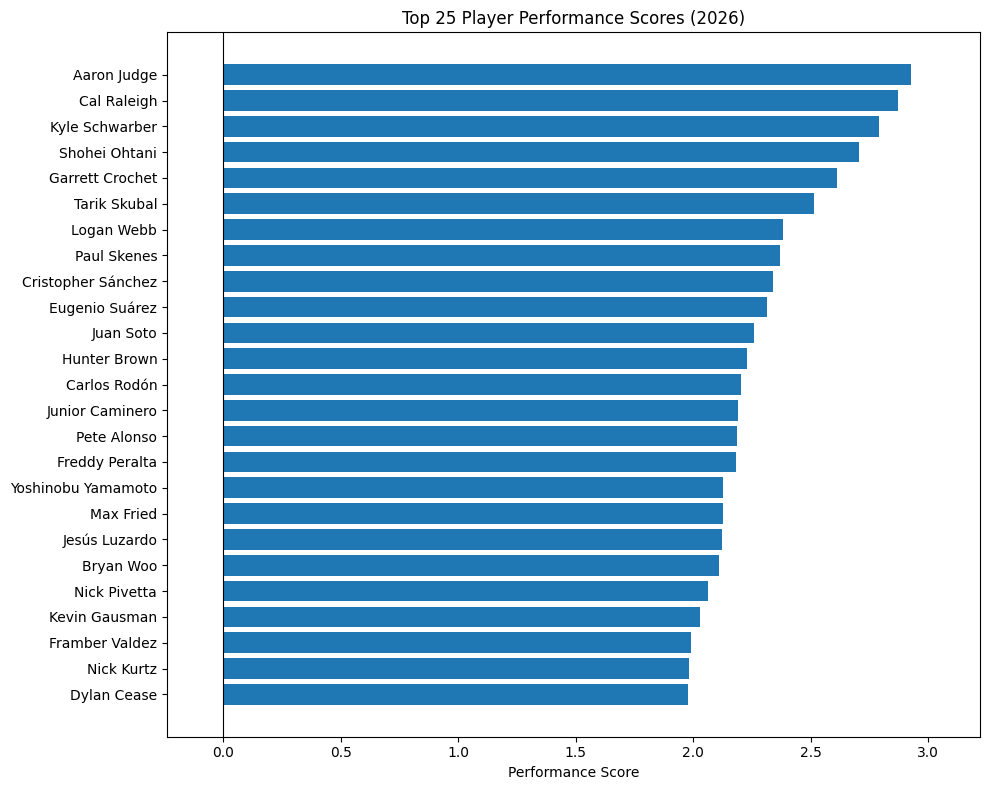

In [924]:
if HAS_MATPLOTLIB:
    plot_performance = top25_performance.sort_values("performance_raw", ascending=True)
    performance_axis_min = min(0, star_rankings.loc[star_rankings["target_season"] == top_players_season, "performance_raw"].min() * 1.10)
    performance_axis_max = max(1, top25_performance["performance_raw"].max() * 1.10)
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(plot_performance["player_name"], plot_performance["performance_raw"])
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"Top 25 Player Performance Scores ({top_players_season})")
    ax.set_xlabel("Performance Score")
    ax.set_ylabel("")
    ax.set_xlim(performance_axis_min, performance_axis_max)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping top-25 performance bar chart: matplotlib is not installed.")

### Current Player Relevance: Leader Factor

The current-season leader factor captures players who are currently leading or near the league lead in important categories. These players can add excitement because fans may value seeing players who are having especially strong seasons.

This factor uses home runs, hits, strikeouts, and saves. To avoid same-game leakage, the statistics are lagged so that only performance through the day before the game is used. This makes the current-season leader factor a pre-game available signal.

In [925]:
leader_factor_summary = (
    panel.groupby("season")["current_season_leader_factor_raw"]
    .describe()
    .round(3)
)

leader_factor_summary

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
2024,"4,858.000",0.835,0.469,0.000,0.505,0.755,1.130,3.000
2025,"4,860.000",0.819,0.474,0.000,0.430,0.780,1.110,2.675
2026,"1,772.000",0.872,0.400,0.000,0.570,0.805,1.110,2.105


In [926]:
panel.sort_values("current_season_leader_factor_raw", ascending=False)[
    [
        "season",
        "game_date",
        "team",
        "opponent",
        "current_season_leader_factor_raw",
        "current_top_batter_name",
        "current_top_hr_player",
        "current_top_hr_rank",
        "current_top_hits_player",
        "current_starter_so_rank",
        "current_team_saves_player",
    ]
].head(15)

,season,game_date,team,opponent,current_season_leader_factor_raw,current_top_batter_name,current_top_hr_player,current_top_hr_rank,current_top_hits_player,current_starter_so_rank,current_team_saves_player
17,2024,2024-03-28,Los Angeles Dodgers,St. Louis Cardinals,3.000,Mookie Betts,Mookie Betts,1.000,Mookie Betts,2.000,Evan Phillips
1138,2024,2024-05-10,Los Angeles Dodgers,San Diego Padres,2.800,Shohei Ohtani,Shohei Ohtani,2.000,Shohei Ohtani,1.000,Evan Phillips
1311,2024,2024-05-16,Los Angeles Dodgers,Cincinnati Reds,2.800,Shohei Ohtani,Shohei Ohtani,2.000,Shohei Ohtani,1.000,Evan Phillips
6187,2025,2025-05-16,New York Yankees,New York Mets,2.675,Aaron Judge,Aaron Judge,1.000,Aaron Judge,4.000,Luke Weaver
1479,2024,2024-05-22,Los Angeles Dodgers,Arizona Diamondbacks,2.675,Shohei Ohtani,Shohei Ohtani,4.000,Shohei Ohtani,1.000,Evan Phillips
487,2024,2024-04-15,Los Angeles Dodgers,Washington Nationals,2.560,Mookie Betts,Mookie Betts,3.000,Mookie Betts,3.000,Evan Phillips
4899,2025,2025-03-28,Los Angeles Dodgers,Detroit Tigers,2.550,Shohei Ohtani,Shohei Ohtani,1.000,Shohei Ohtani,18.000,Blake Treinen
224,2024,2024-04-05,Los Angeles Dodgers,Chicago Cubs,2.550,Mookie Betts,Mookie Betts,1.000,Mookie Betts,16.000,Evan Phillips
181,2024,2024-04-03,Los Angeles Dodgers,San Francisco Giants,2.550,Mookie Betts,Mookie Betts,1.000,Mookie Betts,22.000,Evan Phillips
11,2024,2024-03-28,San Diego Padres,San Francisco Giants,2.545,Manny Machado,Manny Machado,1.000,Jake Cronenworth,2.000,Robert Suarez


### Late-Game Staleness Assumption

Beer and hot dog purchasing is assumed to effectively close after the 7th inning. Under the 9/9/9 framing, the late innings matter because they determine how long fans must wait after the concession window has closed. Longer 8th and 9th innings reduce the experience by increasing the time between the assumed cutoff and the end of the game.

Actual staleness is measured from the first play of the 8th inning to the final play of the game. Temperature adjusts the staleness penalty, reflecting the assumption that warmer or colder weather affects the cost of waiting. We tested whether bullpen fatigue or bullpen quality could predict this late-game duration, but it did not meaningfully improve over a fixed 2024 average on 2025 holdout data.

In [927]:
staleness_summary = (
    panel.loc[panel["is_home"] == 1]
    .groupby("season")["post_cutoff_minutes"]
    .describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90])
    .round(2)
)

staleness_summary

,count,mean,std,min,10%,25%,50%,75%,90%,max
season,,,,,,,,,,
2024,"2,427.000",33.280,14.860,5.860,20.210,24.280,30.560,38.200,48.480,248.180
2025,"2,425.000",33.480,13.880,12.430,20.090,24.560,30.890,38.500,48.650,187.420
2026,886.000,34.380,13.300,13.180,21.270,25.320,31.840,39.760,49.780,117.670


In [928]:
bullpen_results.round(3)

,model,alpha,n_features,mae_minutes,rmse_minutes,r2,mae_improvement_vs_fixed,rmse_improvement_vs_fixed
0,fixed_2024_mean,NaN,0,9.570,13.879,-0.000,0.000,0.000
1,context_only_ridge,250.000,64,9.546,13.870,0.001,0.024,0.009
2,bullpen_only_ridge,500.000,88,9.644,14.018,-0.020,-0.074,-0.139
3,context_plus_bullpen_ridge,500.000,152,9.621,14.000,-0.018,-0.051,-0.121


## 5. Results

### Final 9/9/9 Index Results

The final index combines affordability, game quality, player appeal, current-season relevance, and late-game staleness. Scores above 100 are above the 2024 baseline average, while scores below 100 are below the baseline average. Higher scores represent better 9/9/9 value under the project's definition: lower concession cost, better realized game quality, stronger player appeal, and less late-game staleness.

In [929]:
team_summary = (
    panel.groupby(["season", "team"])
    .agg(
        games=("game_pk", "nunique"),
        avg_index=("999_optimality_index", "mean"),
        avg_cost=("concession_999_cost", "mean"),
        avg_game_quality=("game_quality_raw", "mean"),
        avg_superstar=("lineup_superstar_factor_raw", "mean"),
        avg_current_leader=("current_season_leader_factor_raw", "mean"),
        avg_staleness=("staleness_raw", "mean"),
    )
    .round(3)
    .reset_index()
)

team_summary["season_rank"] = (
    team_summary.groupby("season")["avg_index"]
    .rank(method="first", ascending=False)
    .astype(int)
)

team_summary.sort_values(["season", "season_rank"]).head(20)

,season,team,games,avg_index,avg_cost,avg_game_quality,avg_superstar,avg_current_leader,avg_staleness,season_rank
1,2024,Atlanta Braves,162,111.916,82.080,6.480,2.755,1.533,34.553,1
11,2024,Kansas City Royals,162,109.488,82.260,6.223,2.413,1.244,34.364,2
18,2024,New York Yankees,162,109.263,112.140,7.123,3.155,1.654,38.367,3
13,2024,Los Angeles Dodgers,162,108.650,136.620,7.186,4.029,1.684,36.279,4
28,2024,Toronto Blue Jays,162,107.277,63.990,5.284,1.881,0.713,34.835,5
7,2024,Cleveland Guardians,161,106.950,86.760,6.027,1.707,1.286,33.514,6
0,2024,Arizona Diamondbacks,162,106.569,73.080,7.003,1.356,0.768,36.924,7
20,2024,Philadelphia Phillies,162,106.489,116.010,6.831,3.394,0.940,36.220,8
24,2024,Seattle Mariners,162,105.337,82.260,6.190,1.726,0.715,34.905,9
25,2024,St. Louis Cardinals,162,104.466,118.620,5.457,3.741,0.802,37.779,10


In [930]:
top_games = (
    panel.sort_values(["season", "999_optimality_index"], ascending=[True, False])
    .groupby("season")
    .head(10)
)

top_games[
    [
        "season",
        "game_date",
        "team",
        "opponent",
        "is_home",
        "999_optimality_index",
        "concession_999_cost",
        "game_quality_raw",
        "lineup_superstar_factor_raw",
        "current_season_leader_factor_raw",
        "staleness_raw",
        "top_star_player_names",
    ]
].round(3)

/var/folders/gw/wl7rp7h9787cvm8ly8l59mjm0000gn/T/ipykernel_2475/2015842437.py:22: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(3)


,season,game_date,team,opponent,is_home,999_optimality_index,concession_999_cost,game_quality_raw,lineup_superstar_factor_raw,current_season_leader_factor_raw,staleness_raw,top_star_player_names
4586,2024,2024-09-19,Atlanta Braves,Cincinnati Reds,0,135.467,82.080,23.450,2.538,2.420,41.735,Matt Olson|Marcell Ozuna|Jorge Soler
4070,2024,2024-08-31,Toronto Blue Jays,Minnesota Twins,0,134.124,63.990,23.500,2.000,1.085,25.738,Vladimir Guerrero Jr.|George Springer|Daulton ...
4580,2024,2024-09-19,Los Angeles Dodgers,Miami Marlins,0,133.736,136.620,25.850,4.363,1.745,36.829,Mookie Betts|Shohei Ohtani|Freddie Freeman
1995,2024,2024-06-11,Los Angeles Dodgers,Texas Rangers,1,132.343,136.620,24.050,4.211,1.195,16.434,Mookie Betts|Shohei Ohtani|Freddie Freeman
802,2024,2024-04-27,New York Yankees,Milwaukee Brewers,0,131.027,112.140,22.450,3.132,1.720,27.810,Aaron Judge|Giancarlo Stanton|Juan Soto
...,...,...,...,...,...,...,...,...,...,...,...,...
9904,2026,2026-04-02,Atlanta Braves,Arizona Diamondbacks,0,129.129,83.070,23.300,2.157,0.905,35.225,Ronald Acuña Jr.|Matt Olson|Ozzie Albies
10353,2026,2026-04-19,New York Yankees,Kansas City Royals,1,129.086,83.250,14.250,5.040,1.655,31.359,Aaron Judge|Paul Goldschmidt|Cody Bellinger
11109,2026,2026-05-17,Cleveland Guardians,Cincinnati Reds,1,128.581,86.760,19.950,2.340,1.250,21.358,José Ramírez|Steven Kwan|Kyle Manzardo
10697,2026,2026-05-02,New York Yankees,Baltimore Orioles,1,128.529,83.250,13.350,4.811,1.655,24.268,Aaron Judge|Cody Bellinger|Jazz Chisholm Jr.


In [931]:
bottom_games = (
    panel.sort_values(["season", "999_optimality_index"], ascending=[True, True])
    .groupby("season")
    .head(5)
)

bottom_games[
    [
        "season",
        "game_date",
        "team",
        "opponent",
        "is_home",
        "999_optimality_index",
        "concession_999_cost",
        "game_quality_raw",
        "staleness_raw",
    ]
].round(3)

/var/folders/gw/wl7rp7h9787cvm8ly8l59mjm0000gn/T/ipykernel_2475/450270764.py:19: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(3)


,season,game_date,team,opponent,is_home,999_optimality_index,concession_999_cost,game_quality_raw,staleness_raw
980,2024,2024-05-04,Chicago White Sox,St. Louis Cardinals,0,48.831,146.520,6.250,275.479
2507,2024,2024-06-30,New York Mets,Houston Astros,1,55.529,134.100,2.750,257.501
3441,2024,2024-08-08,Washington Nationals,San Francisco Giants,1,55.781,210.510,3.100,167.771
981,2024,2024-05-04,St. Louis Cardinals,Chicago White Sox,1,61.298,118.620,4.150,275.479
3232,2024,2024-07-30,Washington Nationals,Arizona Diamondbacks,0,67.899,210.510,-5.950,31.657
5794,2025,2025-05-01,Minnesota Twins,Cleveland Guardians,0,66.452,81.810,1.600,202.414
9389,2025,2025-09-16,Washington Nationals,Atlanta Braves,1,68.437,210.510,-1.750,60.943
8038,2025,2025-07-28,Boston Red Sox,Minnesota Twins,0,68.601,153.360,3.500,151.387
4877,2025,2025-03-27,Washington Nationals,Philadelphia Phillies,1,69.191,210.510,3.300,85.691
7738,2025,2025-07-13,Washington Nationals,Milwaukee Brewers,0,70.658,210.510,-1.800,43.171


### 2025 Game And Team Rankings

The 2025 rankings show three different views of the index. The best overall game score uses the final `999_optimality_index`. The team average superstar/performance rating uses each team's average `lineup_superstar_factor_raw`. The cheapest games use `concession_999_cost`; because ticket prices are excluded, this is the team-season concession cost for the 9/9/9 challenge.

In [932]:
def game_label(row):
    matchup = "vs" if row["is_home"] else "@"
    return f"{row['team']} {matchup} {row['opponent']} ({row['game_date'].date()})"


season_rank_graph_rows = []

ranking_graph_season = 2025
season_games = panel.loc[panel["season"] == ranking_graph_season].copy()

best_overall = season_games.sort_values("999_optimality_index", ascending=False).head(10).copy()
best_overall["chart"] = "Best overall game score"
best_overall["rank_value"] = best_overall["999_optimality_index"]
best_overall["rank_label"] = best_overall.apply(game_label, axis=1)
season_rank_graph_rows.append(best_overall)

team_star_factor_2025 = (
    season_games.groupby("team", as_index=False)
    .agg(
        season=("season", "first"),
        games=("game_pk", "nunique"),
        avg_superstar_performance_rating=("lineup_superstar_factor_raw", "mean"),
    )
    .sort_values("avg_superstar_performance_rating", ascending=False)
)

team_star_factor_2025["chart"] = "Team average superstar/performance rating"
team_star_factor_2025["rank_value"] = team_star_factor_2025["avg_superstar_performance_rating"]
team_star_factor_2025["rank_label"] = (
    team_star_factor_2025["team"]
    + " ("
    + team_star_factor_2025["avg_superstar_performance_rating"].round(2).astype(str)
    + ")"
)
season_rank_graph_rows.append(team_star_factor_2025)

cheapest_games = (
    season_games.sort_values(["concession_999_cost", "team", "game_date"])
    .drop_duplicates(["team"])
    .head(10)
    .copy()
)
cheapest_games["chart"] = "Cheapest games"
cheapest_games["rank_value"] = cheapest_games["concession_999_cost"]
cheapest_games["rank_label"] = cheapest_games["team"]
season_rank_graph_rows.append(cheapest_games)

season_rank_graph_data = pd.concat(season_rank_graph_rows, ignore_index=True)

season_rank_graph_table = season_rank_graph_data[
    ["chart", "rank_label", "rank_value"]
].round(3)

season_rank_graph_table

,chart,rank_label,rank_value
0,Best overall game score,New York Yankees vs Milwaukee Brewers (2025-03...,148.375
1,Best overall game score,New York Yankees @ Tampa Bay Rays (2025-08-19),145.307
2,Best overall game score,New York Yankees @ Baltimore Orioles (2025-04-29),143.902
3,Best overall game score,New York Yankees vs Washington Nationals (2025...,138.976
4,Best overall game score,Kansas City Royals vs Toronto Blue Jays (2025-...,136.515
...,...,...,...
45,Cheapest games,New York Yankees,83.250
46,Cheapest games,Toronto Blue Jays,86.040
47,Cheapest games,Cleveland Guardians,86.760
48,Cheapest games,Colorado Rockies,90.000


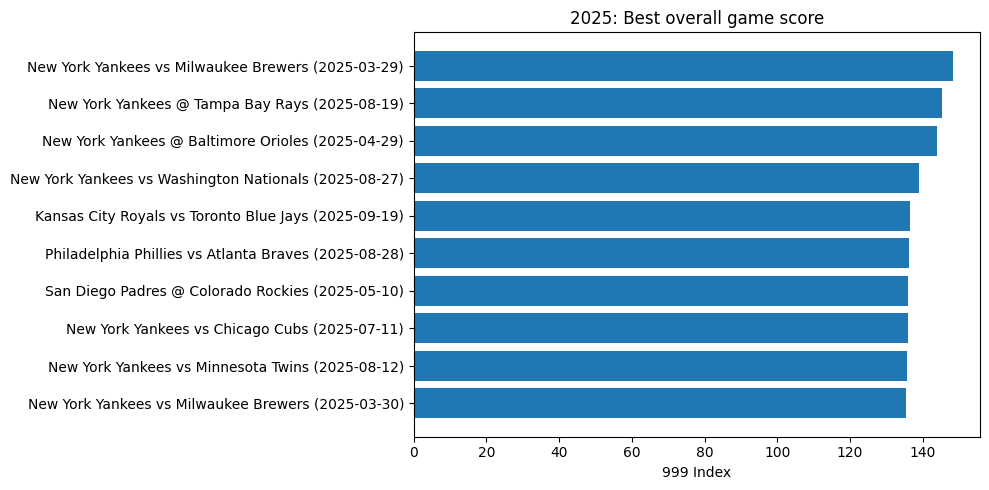

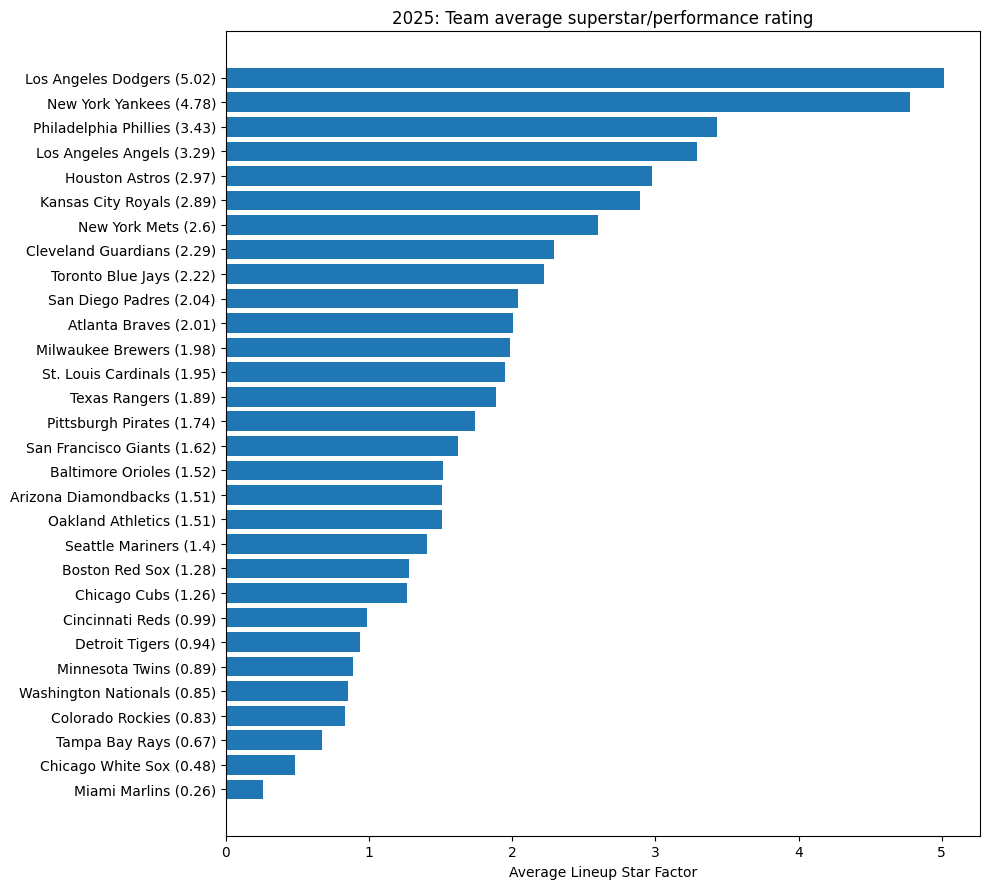

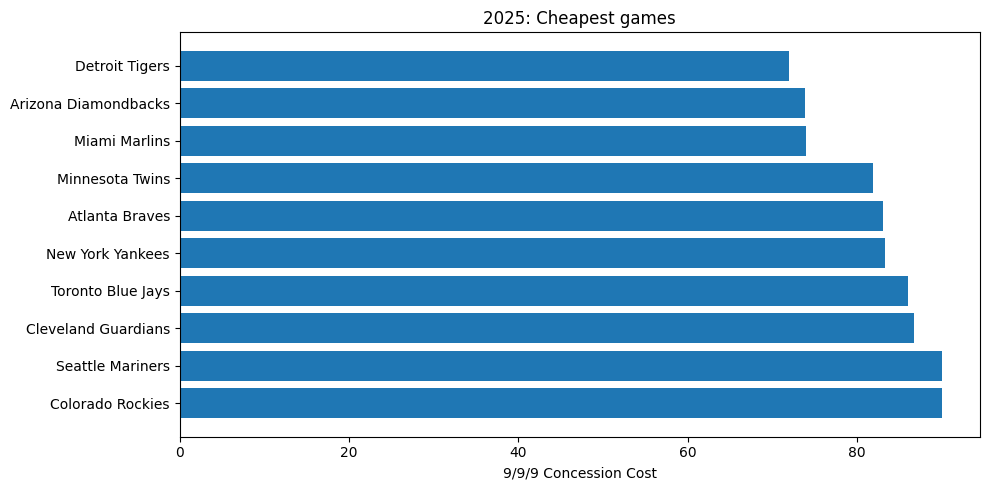

In [933]:
if HAS_MATPLOTLIB:
    chart_order = [
        ("Best overall game score", "999 Index"),
        ("Team average superstar/performance rating", "Average Lineup Star Factor"),
        ("Cheapest games", "9/9/9 Concession Cost"),
    ]

    for chart_name, x_label in chart_order:
        chart_data = season_rank_graph_data.loc[
            season_rank_graph_data["chart"] == chart_name
        ].copy()

        if chart_name == "Cheapest games":
            plot_data = chart_data.sort_values("rank_value", ascending=False)
        else:
            plot_data = chart_data.sort_values("rank_value", ascending=True)

        figsize = (10, 9) if chart_name == "Team average superstar/performance rating" else (10, 5)
        fig, ax = plt.subplots(figsize=figsize)
        ax.barh(plot_data["rank_label"], plot_data["rank_value"])
        ax.set_title(f"{ranking_graph_season}: {chart_name}")
        ax.set_xlabel(x_label)
        ax.set_ylabel("")
        plt.tight_layout()
        plt.show()
else:
    print("Skipping 2025 ranking graphs: matplotlib is not installed.")

### 2025 Experience Value Per Dollar

The value-per-dollar graph answers a different question from the final index: which teams give the most experience and player value per dollar spent on the 9/9/9 concession challenge? The numerator uses only positive experience variables, so concession cost is not double-counted:
- realized game quality
- lineup superstar/performance factor
- current-season leader factor

The results show how teams can rank differently when looking at value relative to concession cost. The New York Yankees rank highly because they combine strong player appeal with relatively reasonable concession prices. The Los Angeles Dodgers have many talented players, but expensive concessions lower their value-per-dollar ranking. Teams such as the Atlanta Braves, Detroit Tigers, and Arizona Diamondbacks benefit from having exciting players while still keeping concession prices comparatively affordable. Teams with fewer stars can still score reasonably well if concessions are cheap, such as the Miami Marlins, while teams with weaker player appeal and higher prices fall toward the bottom.

In [934]:
value_season = 2025
value_games = panel.loc[panel["season"] == value_season].copy()

baseline_experience = panel.loc[panel["season"] == 2024]
baseline_experience_raw = (
    0.35 * baseline_experience["game_quality_raw_z_train2024"]
    + 0.15 * baseline_experience["lineup_superstar_factor_raw_z_train2024"]
    + 0.10 * baseline_experience["current_season_leader_factor_raw_z_train2024"]
)

value_games["experience_player_raw"] = (
    0.35 * value_games["game_quality_raw_z_train2024"]
    + 0.15 * value_games["lineup_superstar_factor_raw_z_train2024"]
    + 0.10 * value_games["current_season_leader_factor_raw_z_train2024"]
)

value_games["experience_player_index"] = (
    100
    + 10
    * (
        (value_games["experience_player_raw"] - baseline_experience_raw.mean())
        / baseline_experience_raw.std()
    )
)

team_value_per_dollar_2025 = (
    value_games.groupby("team", as_index=False)
    .agg(
        avg_experience_player_index=("experience_player_index", "mean"),
        concession_999_cost=("concession_999_cost", "mean"),
    )
)

team_value_per_dollar_2025["experience_player_value_per_dollar"] = (
    team_value_per_dollar_2025["avg_experience_player_index"]
    / team_value_per_dollar_2025["concession_999_cost"]
)

team_value_per_dollar_2025 = (
    team_value_per_dollar_2025
    .sort_values("experience_player_value_per_dollar", ascending=False)
)

value_per_dollar_top_bottom_2025 = pd.concat(
    [
        team_value_per_dollar_2025.head(5).assign(value_group="Top 5"),
        team_value_per_dollar_2025.tail(5).assign(value_group="Bottom 5"),
    ],
    ignore_index=True,
)

value_per_dollar_top_bottom_display = value_per_dollar_top_bottom_2025[
    ["value_group", "team", "experience_player_value_per_dollar"]
].round(3).set_index(["value_group", "team"])

value_per_dollar_top_bottom_display

experience_player_value_per_dollar
value_group team                                                    
Top 5       New York Yankees                                   1.407
            Detroit Tigers                                     1.375
            Arizona Diamondbacks                               1.363
            Miami Marlins                                      1.237
            Atlanta Braves                                     1.202
Bottom 5    Chicago White Sox                                  0.635
            Texas Rangers                                      0.583
            St. Louis Cardinals                                0.551
            Los Angeles Dodgers                                0.537
            Washington Nationals                               0.456

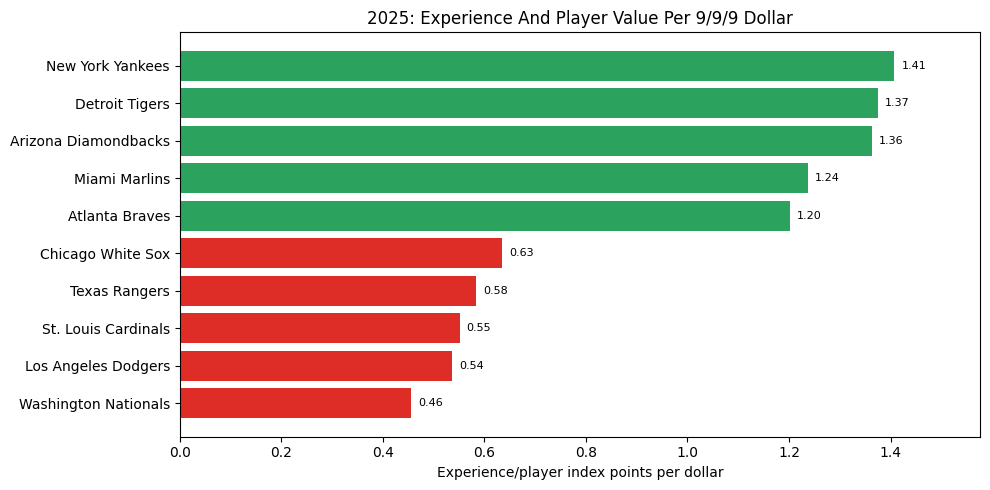

In [935]:
if HAS_MATPLOTLIB:
    plot_value = value_per_dollar_top_bottom_2025.sort_values(
        "experience_player_value_per_dollar",
        ascending=True,
    )
    bar_colors = ["#2ca25f" if group == "Top 5" else "#de2d26" for group in plot_value["value_group"]]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(plot_value["team"], plot_value["experience_player_value_per_dollar"], color=bar_colors)
    label_offset = plot_value["experience_player_value_per_dollar"].max() * 0.01
    for team, value in zip(plot_value["team"], plot_value["experience_player_value_per_dollar"]):
        ax.text(value + label_offset, team, f"{value:.2f}", va="center", fontsize=8)
    ax.set_xlim(0, plot_value["experience_player_value_per_dollar"].max() * 1.12)
    ax.set_title(f"{value_season}: Experience And Player Value Per 9/9/9 Dollar")
    ax.set_xlabel("Experience/player index points per dollar")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping value-per-dollar graph: matplotlib is not installed.")

### Index Stability Across Seasons

The normalized index stayed close to a mean of 100 and a standard deviation of 10 across the evaluated seasons. The 2024 season is the baseline season, so it is expected to be the most centered. The 2025 and completed 2026 results remaining close to the same scale suggests that the index is reasonably stable across seasons.

In [936]:
season_mean_std = (
    panel.groupby("season")
    .agg(
        team_game_rows=("game_pk", "size"),
        games=("game_pk", "nunique"),
        mean_index=("999_optimality_index", "mean"),
        std_index=("999_optimality_index", "std"),
        min_index=("999_optimality_index", "min"),
        q25_index=("999_optimality_index", lambda x: x.quantile(0.25)),
        median_index=("999_optimality_index", "median"),
        q75_index=("999_optimality_index", lambda x: x.quantile(0.75)),
        max_index=("999_optimality_index", "max"),
    )
    .round(3)
    .reset_index()
)

season_mean_std

,season,team_game_rows,games,mean_index,std_index,min_index,q25_index,median_index,q75_index,max_index
0,2024,4858,2429,100.000,10.001,48.831,93.194,99.857,106.719,135.467
1,2025,4860,2430,99.833,10.172,66.452,93.087,99.484,106.373,148.375
2,2026,1772,886,99.946,9.843,62.727,93.261,99.446,106.234,142.717


### Pre-Game Holdout Check

The holdout check is the closest part of the project to a predictive model. It uses only variables that can reasonably be known before the game or after lineups are released:
- 9/9/9 concession cost
- lineup superstar factor
- lagged current-season leader factor
- home/away indicator

The target is whether a 2025 team-game becomes a high-scoring game according to the retrospective 9/9/9 index. This does not predict wins or attendance. Instead, it tests whether pre-game information can identify games that later score well under this project's fan experience index. The above-average 2025 holdout AUC is about 0.825, which suggests the pre-game features have meaningful ability to separate stronger and weaker index outcomes.

In [937]:
pregame_auc.round(3)

,target,threshold_from_2024,test_positive_rate_2025,model,auc_2025,n_train_2024,n_test_2025
0,above_100,100.000,0.478,pregame_component_score,0.824,4858,4860
1,above_100,100.000,0.478,logistic_known_pregame_features,0.825,4858,4860
2,top_quartile_vs_2024_q75,106.719,0.239,pregame_component_score,0.806,4858,4860
3,top_quartile_vs_2024_q75,106.719,0.239,logistic_known_pregame_features,0.811,4858,4860
4,top_decile_vs_2024_q90,113.216,0.094,pregame_component_score,0.831,4858,4860
5,top_decile_vs_2024_q90,113.216,0.094,logistic_known_pregame_features,0.835,4858,4860


### Component Relationships

The component correlations describe relationships inside the created index. These should not be interpreted as causal effects, but they help show which variables move most closely with the final index in each season.

In [938]:
component_cols = [
    "game_quality_raw",
    "lineup_superstar_factor_raw",
    "current_season_leader_factor_raw",
    "concession_999_cost",
    "staleness_raw",
]

correlation_rows = []
for season, group in panel.groupby("season"):
    for col in component_cols:
        correlation_rows.append(
            {
                "season": season,
                "variable": col,
                "correlation_with_index": group[col].corr(group["999_optimality_index"]),
            }
        )

component_correlations = pd.DataFrame(correlation_rows).round(3)
component_correlations

,season,variable,correlation_with_index
0,2024,game_quality_raw,0.702
1,2024,lineup_superstar_factor_raw,0.466
2,2024,current_season_leader_factor_raw,0.448
3,2024,concession_999_cost,-0.528
4,2024,staleness_raw,-0.263
5,2025,game_quality_raw,0.704
6,2025,lineup_superstar_factor_raw,0.382
7,2025,current_season_leader_factor_raw,0.401
8,2025,concession_999_cost,-0.491
9,2025,staleness_raw,-0.212


## 6. Conclusion

### Limitations And Data Quality

The main limitations of this project come from data availability and the subjective nature of fan enjoyment. Concession prices are public secondary-source estimates and may not capture every stand, promotion, or serving-size definition. Concession prices are also mostly fixed within a season, so the 9/9/9 cost is mainly a stadium/team-season affordability variable rather than a game-specific price.

Some variables are retrospective, especially actual game quality and actual late-game staleness. Ticket prices were excluded because reliable historical primary-market game-level prices were not available. The index weights are interpretable project choices rather than optimized black-box model parameters.

### Final Conclusion

The main takeaway from this project is that the best 9/9/9 experiences come from teams that combine exciting players, solid game quality, and reasonable concession prices. In the 2025 value-per-dollar results, the New York Yankees rank as the best team because they combine strong player appeal with comparatively reasonable concession prices. Several teams with fewer major stars can still score well if their concession prices are low, which shows that affordability can offset weaker player appeal.

If this project were expanded in the future, the biggest improvement would be adding reliable primary-market ticket prices. That would allow the index to measure the full cost of attending a game, not only the concession cost after entering the stadium. Other improvements could include official concession data, more seasons of data, and fan survey data to compare the index against actual fan enjoyment.

## 7. References

Cheapism. "MLB Beer and Hot Dog Prices." Used for 2025 and 2026 team-level concession price estimates.  
https://www.cheapism.com/mlb-beer-hot-dog-prices/

Datawrapper / Washington Post. 2024 MLB hot dog price dataset. Used for 2024 team-level hot dog prices.  
https://datawrapper.dwcdn.net/MzJPi/1/dataset.csv

Major League Baseball. MLB StatsAPI live game feed endpoint. Used for game scores, lineups, starters, box-score events, weather, attendance, and late-game timing.  
https://statsapi.mlb.com/api/v1.1/game/{gamePk}/feed/live

Major League Baseball. MLB StatsAPI people awards endpoint. Used for player award and accolade counts in the superstar factor.  
https://statsapi.mlb.com/api/v1/people/{personId}/awards

Major League Baseball. MLB StatsAPI schedule endpoint. Used for regular-season game dates, teams, venues, and game IDs.  
https://statsapi.mlb.com/api/v1/schedule

Major League Baseball. MLB StatsAPI season statistics endpoint. Used for prior-season hitting and pitching statistics in the player performance factor.  
https://statsapi.mlb.com/api/v1/stats?stats=season&group=hitting|pitching&playerPool=ALL

Major League Baseball. MLB StatsAPI by-date-range statistics endpoint. Used for lagged current-season leader factors before each game.  
https://statsapi.mlb.com/api/v1/stats?stats=byDateRange&group=hitting|pitching&playerPool=ALL

Radio One / 107.5 The Fan. "Price of Beer at Every MLB Stadium." Used for 2024 team-level beer prices; the source reports that values are based on a 2024 Statista study.  
https://1075thefan.com/playlist/price-of-beer-at-every-mlb-stadium/

WebstaurantStore. "Beer, Hot Dog, and Ticket Prices at Major League Baseball Parks." Used as a validation source for 2025 concession estimates.  
https://www.webstaurantstore.com/blog/628/beer-hot-dog-and-ticket-prices-at-major-league-baseball-parks.html

Yahoo Sports / List Wire. "How much does a hot dog and beer cost at every MLB stadium?" Used as a cross-check and republication source for 2025 and 2026 concession estimates.  
https://sports.yahoo.com/articles/much-does-hot-dog-beer-195238572.html